In [12]:
import astropy.constants as const
import astropy.units as u
from scipy import integrate
import matplotlib.pyplot as plt
import numpy as np

from plotting import label_axes

In [13]:
from typing import cast
from astropy.cosmology import WMAP9 as cosmo
from astropy.cosmology import Cosmology

cosmo = cast(Cosmology, cosmo)


def abs_dt_dz_Myr(z: float) -> float:
    return (
        (1 / ((1 + z) * cosmo.H0 * np.sqrt((1 + z) ** 3 * cosmo.Om0 + cosmo.Ode0)))
        .to(u.Myr)
        .value
    )

In [47]:
z_grid = np.logspace(-2, 1, 300)
t_Hubble = 13.787 * u.Gyr

# Time and redshift differentials


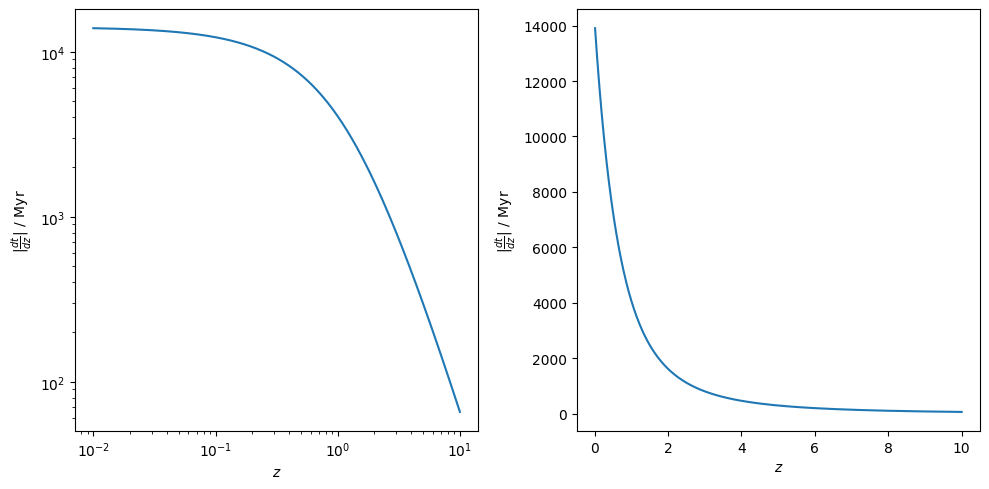

In [58]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 5))

dt_dz = u.Quantity([abs_dt_dz_Myr(z) for z in z_grid]) * u.Myr

for i, ax in enumerate(axes):
    ax.plot(z_grid, dt_dz)
    label_axes(ax, "z", " | \\frac{dt}{dz} | ")
    if i == 0:
        ax.set_xscale("log")
        ax.set_yscale("log")

fig.tight_layout()


# Cosmic time vs redshift

In [49]:
def cosmic_time(z: float) -> float:
    res, tol = integrate.quad(abs_dt_dz_Myr, z, np.inf)
    return res * u.Myr

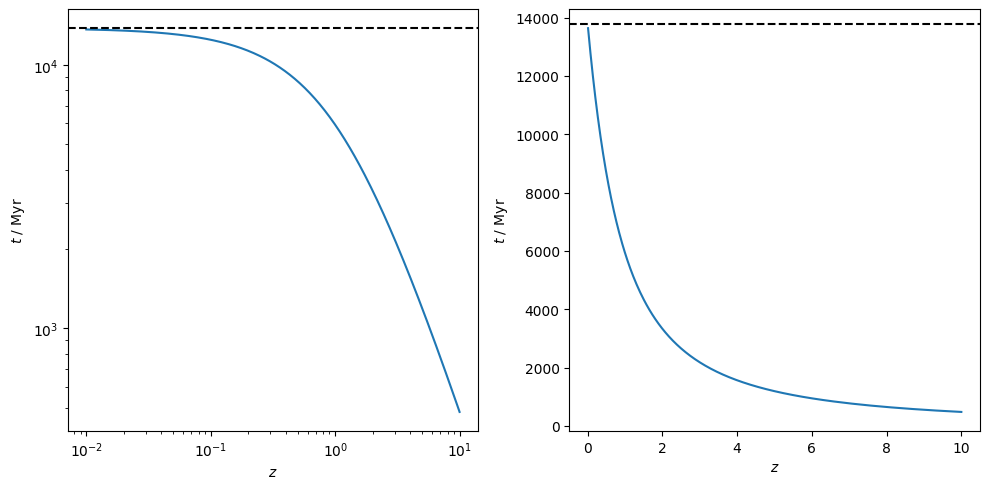

In [52]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 5))

t_cosmic = u.Quantity([cosmic_time(z) for z in z_grid])

for i, ax in enumerate(axes):
    ax.plot(z_grid, t_cosmic)
    ax.axhline(t_Hubble, color="k", linestyle="--")
    label_axes(ax, "z", "t")
    if i == 0:
        ax.set_xscale("log")
        ax.set_yscale("log")

fig.tight_layout()

# Light travel distance

In [55]:
def D_T(z: float) -> u.Quantity[u.Mpc]:
    res, tol = integrate.quad(abs_dt_dz_Myr, 0, z)
    return ((res * u.Myr) * const.c).to(u.Mpc)

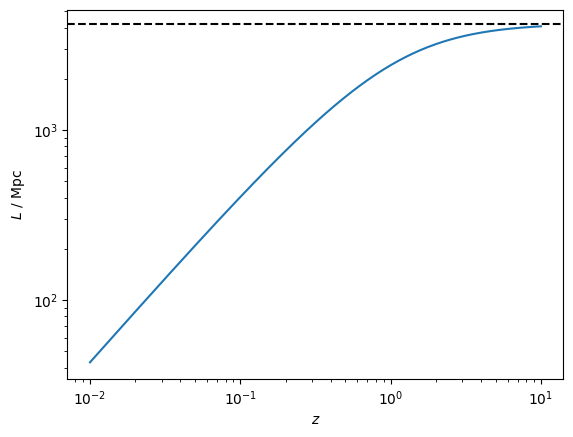

In [56]:
fig, ax = plt.subplots()

ax.loglog(z_grid, u.Quantity([D_T(z) for z in z_grid]))
ax.axhline(const.c * t_Hubble, color="k", linestyle="--")
label_axes(ax, "z", "L")
plt.show()

# Sampling in time vs. in redshift

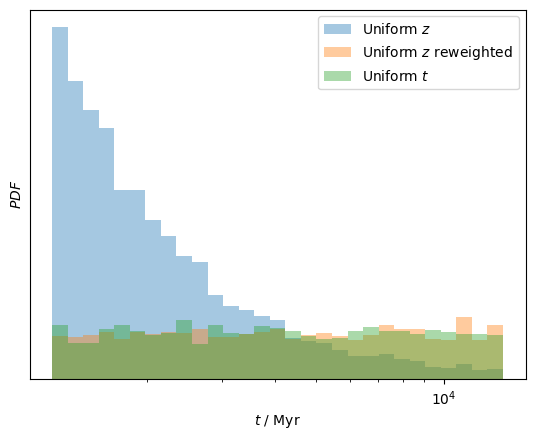

In [59]:
z_max = 5
t_min = cosmic_time(z_max)

fig, ax = plt.subplots()

sample_size = 3_000
z_sample = np.random.uniform(low=0, high=z_max, size=sample_size)
t_sample = u.Quantity([cosmic_time(z) for z in z_sample])
t_sample_weight = u.Quantity([abs_dt_dz_Myr(z) for z in z_sample]) * u.Myr

bins = np.geomspace(t_min, t_Hubble, 30).to(u.Myr)

ax.hist(t_sample, bins=bins, density=True, alpha=0.4, label="Uniform $z$")
ax.hist(t_sample, bins=bins, weights=t_sample_weight, density=True, alpha=0.4, label="Uniform $z$ reweighted")

t_sample_uni = np.random.uniform(low=t_min.to(u.Myr).value, high=t_Hubble.to(u.Myr).value, size=sample_size) * u.Myr
ax.hist(t_sample_uni, bins=bins, density=True, alpha=0.4, label="Uniform $t$")

ax.set_xscale("log")
ax.set_yticks([])
ax.legend()
label_axes(ax, "t", "PDF")

ax.plot()

plt.show()
